In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, roc_auc_score
import joblib

df    = pd.read_csv('../data/processed/deliveries_clean.csv')
X     = df.drop('is_delayed', axis=1)
y     = df['is_delayed']
model = joblib.load('../models/best_model.pkl')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
predictions   = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]
print(f"Model loaded: {type(model).__name__}")

Model loaded: LogisticRegression


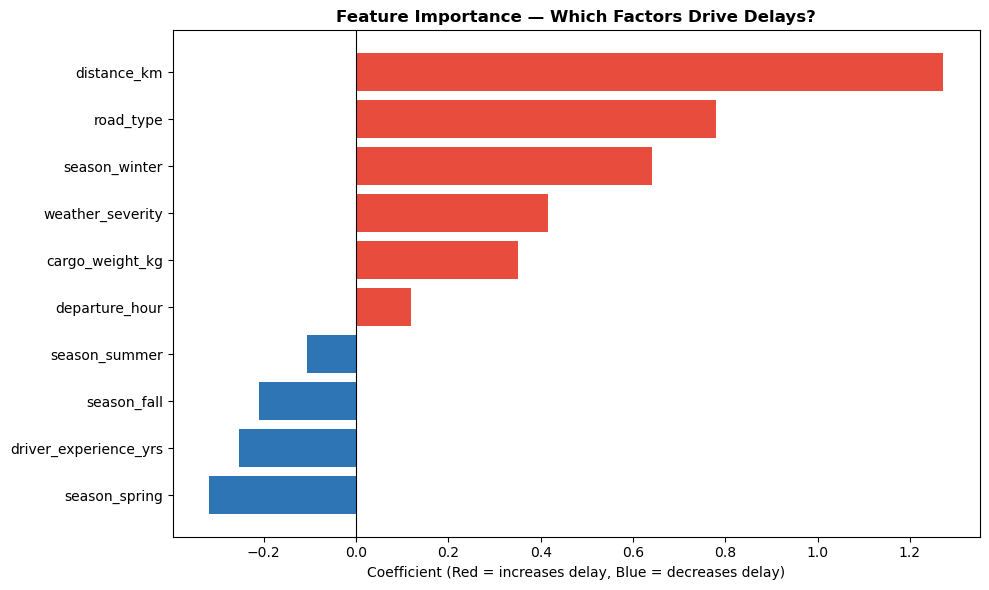

In [4]:
# Which features does the model rely on most?
feature_names = X.columns.tolist()
coefficients  = model.coef_[0]

importance_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=True)

colors = ['#E74C3C' if c > 0 else '#2E75B6'
          for c in importance_df['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'],
         importance_df['Coefficient'],
         color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Importance — Which Factors Drive Delays?',
          fontweight='bold')
plt.xlabel('Coefficient (Red = increases delay, Blue = decreases delay)')
plt.tight_layout()
plt.savefig('../charts/chart8_feature_importance.png')
plt.show()